# PROJECT_Tobacco Use and Mortality, 2004-2015

In [1]:
import pandas as pd

# Load all CSV files
admissions = pd.read_csv("admissions.csv")
fatalities = pd.read_csv("fatalities.csv")
metrics = pd.read_csv("metrics.csv")
prescriptions = pd.read_csv("prescriptions.csv")
smokers = pd.read_csv("smokers.csv")

# List of datasets for easy looping
dataframes = {
    "Admissions": admissions,
    "Fatalities": fatalities,
    "Metrics": metrics,
    "Prescriptions": prescriptions,
    "Smokers": smokers
}

# Check each dataset
for name, df in dataframes.items():
    print(f"===== {name} DATASET =====")
    print(df.info())            # Summary of columns and data types
    print(df.head())            # First 5 rows
    print(df.isnull().sum())    # Missing values count
    print("Duplicate Rows:", df.duplicated().sum())
    print("\n")

===== Admissions DATASET =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2079 entries, 0 to 2078
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Year             2079 non-null   object
 1   ICD10 Code       2079 non-null   object
 2   ICD10 Diagnosis  2079 non-null   object
 3   Diagnosis Type   2079 non-null   object
 4   Metric           2079 non-null   object
 5   Sex              1386 non-null   object
 6   Value            2078 non-null   object
dtypes: object(7)
memory usage: 113.8+ KB
None
      Year                                         ICD10 Code  \
0  2014/15                                          All codes   
1  2014/15  C33-C34 & C00-C14 & C15 & C32 & C53 & C67 & C6...   
2  2014/15                                            C00-D48   
3  2014/15                                            J00-J99   
4  2014/15                                            I00-I99   

                    

# Data Cleaning

## Admissions.csv

In [2]:
admissions.info()
admissions.head()
admissions.isnull().sum()
print("Duplicate rows:", admissions.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2079 entries, 0 to 2078
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Year             2079 non-null   object
 1   ICD10 Code       2079 non-null   object
 2   ICD10 Diagnosis  2079 non-null   object
 3   Diagnosis Type   2079 non-null   object
 4   Metric           2079 non-null   object
 5   Sex              1386 non-null   object
 6   Value            2078 non-null   object
dtypes: object(7)
memory usage: 113.8+ KB
Duplicate rows: 0


In [3]:
# Convert Year to integer
admissions['Year'] = pd.to_numeric(admissions['Year'], errors='coerce')

# Convert Value to numeric
admissions['Value'] = pd.to_numeric(admissions['Value'], errors='coerce')

# Fill missing Sex values with "All" (or 'Unknown')
admissions['Sex'].fillna('All', inplace=True)

# Final check
print(admissions.info())
print(admissions.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2079 entries, 0 to 2078
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             0 non-null      float64
 1   ICD10 Code       2079 non-null   object 
 2   ICD10 Diagnosis  2079 non-null   object 
 3   Diagnosis Type   2079 non-null   object 
 4   Metric           2079 non-null   object 
 5   Sex              2079 non-null   object 
 6   Value            2038 non-null   float64
dtypes: float64(2), object(5)
memory usage: 113.8+ KB
None
Year               2079
ICD10 Code            0
ICD10 Diagnosis       0
Diagnosis Type        0
Metric                0
Sex                   0
Value                41
dtype: int64


In [4]:
print(admissions['Year'].unique()[:20])

[nan]


In [5]:
admissions = pd.read_csv("admissions.csv")
print(admissions['Year'].unique()[:20])  # check original values

['2014/15' '2013/14' '2012/13' '2011/12' '2010/11' '2009/10' '2008/09'
 '2007/08' '2006/07' '2005/06' '2004/05']


In [6]:
# Extract first four digits as year
admissions['Year'] = admissions['Year'].str[:4]

# Convert to integer
admissions['Year'] = pd.to_numeric(admissions['Year'], errors='coerce')


In [7]:
# Drop rows where Value is missing (only 41 rows)
admissions.dropna(subset=['Value'], inplace=True)


In [8]:
print(admissions.info())
print(admissions.isnull().sum())
print(admissions.head())

<class 'pandas.core.frame.DataFrame'>
Index: 2078 entries, 0 to 2078
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Year             2078 non-null   int64 
 1   ICD10 Code       2078 non-null   object
 2   ICD10 Diagnosis  2078 non-null   object
 3   Diagnosis Type   2078 non-null   object
 4   Metric           2078 non-null   object
 5   Sex              1386 non-null   object
 6   Value            2078 non-null   object
dtypes: int64(1), object(6)
memory usage: 129.9+ KB
None
Year                 0
ICD10 Code           0
ICD10 Diagnosis      0
Diagnosis Type       0
Metric               0
Sex                692
Value                0
dtype: int64
   Year                                         ICD10 Code  \
0  2014                                          All codes   
1  2014  C33-C34 & C00-C14 & C15 & C32 & C53 & C67 & C6...   
2  2014                                            C00-D48   
3  2014        

In [9]:
# Convert Value to numeric
admissions['Value'] = pd.to_numeric(admissions['Value'], errors='coerce')

# Fill missing Sex with 'All'
admissions['Sex'].fillna('All', inplace=True)

# Verify
print(admissions.info())
print(admissions.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
Index: 2078 entries, 0 to 2078
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             2078 non-null   int64  
 1   ICD10 Code       2078 non-null   object 
 2   ICD10 Diagnosis  2078 non-null   object 
 3   Diagnosis Type   2078 non-null   object 
 4   Metric           2078 non-null   object 
 5   Sex              2078 non-null   object 
 6   Value            2038 non-null   float64
dtypes: float64(1), int64(1), object(5)
memory usage: 129.9+ KB
None
Year                0
ICD10 Code          0
ICD10 Diagnosis     0
Diagnosis Type      0
Metric              0
Sex                 0
Value              40
dtype: int64


In [10]:
admissions.dropna(subset=['Value'], inplace=True)
print(admissions.shape)
print(admissions.isnull().sum())

(2038, 7)
Year               0
ICD10 Code         0
ICD10 Diagnosis    0
Diagnosis Type     0
Metric             0
Sex                0
Value              0
dtype: int64


## Fatalities Dataset

In [12]:
fatalities.info()
fatalities.head()
fatalities.isnull().sum()
print("Duplicate rows:", fatalities.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1749 entries, 0 to 1748
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Year             1749 non-null   int64 
 1   ICD10 Code       1749 non-null   object
 2   ICD10 Diagnosis  1749 non-null   object
 3   Diagnosis Type   1749 non-null   object
 4   Metric           1749 non-null   object
 5   Sex              1166 non-null   object
 6   Value            1749 non-null   object
dtypes: int64(1), object(6)
memory usage: 95.8+ KB
Duplicate rows: 0


In [13]:
# Convert Value to numeric
fatalities['Value'] = pd.to_numeric(fatalities['Value'], errors='coerce')

# Fill missing Sex values
fatalities['Sex'].fillna('All', inplace=True)

# Drop rows where Value is NaN (if any after conversion)
fatalities.dropna(subset=['Value'], inplace=True)

# Verify
print(fatalities.info())
print(fatalities.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
Index: 1729 entries, 0 to 1748
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             1729 non-null   int64  
 1   ICD10 Code       1729 non-null   object 
 2   ICD10 Diagnosis  1729 non-null   object 
 3   Diagnosis Type   1729 non-null   object 
 4   Metric           1729 non-null   object 
 5   Sex              1729 non-null   object 
 6   Value            1729 non-null   float64
dtypes: float64(1), int64(1), object(5)
memory usage: 108.1+ KB
None
Year               0
ICD10 Code         0
ICD10 Diagnosis    0
Diagnosis Type     0
Metric             0
Sex                0
Value              0
dtype: int64


## Metrics Dataset

In [14]:
metrics.info()
metrics.head()
metrics.isnull().sum()
print("Duplicate rows:", metrics.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 9 columns):
 #   Column                                                 Non-Null Count  Dtype  
---  ------                                                 --------------  -----  
 0   Year                                                   36 non-null     int64  
 1   Tobacco Price
Index                                    36 non-null     float64
 2   Retail Prices
Index                                    36 non-null     float64
 3   Tobacco Price Index Relative to Retail Price Index     36 non-null     float64
 4   Real Households' Disposable Income                     36 non-null     float64
 5   Affordability of Tobacco Index                         36 non-null     float64
 6   Household Expenditure on Tobacco                       31 non-null     float64
 7   Household Expenditure Total                            31 non-null     float64
 8   Expenditure on Tobacco as a Percentage of Expenditure

In [15]:
# Fill missing values (e.g., use median for expenditure columns)
metrics.fillna(metrics.median(), inplace=True)

# Verify
print(metrics.info())
print(metrics.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 9 columns):
 #   Column                                                 Non-Null Count  Dtype  
---  ------                                                 --------------  -----  
 0   Year                                                   36 non-null     int64  
 1   Tobacco Price
Index                                    36 non-null     float64
 2   Retail Prices
Index                                    36 non-null     float64
 3   Tobacco Price Index Relative to Retail Price Index     36 non-null     float64
 4   Real Households' Disposable Income                     36 non-null     float64
 5   Affordability of Tobacco Index                         36 non-null     float64
 6   Household Expenditure on Tobacco                       36 non-null     float64
 7   Household Expenditure Total                            36 non-null     float64
 8   Expenditure on Tobacco as a Percentage of Expenditure

## Prescriptions Dataset

In [16]:
prescriptions.info()
prescriptions.head()
prescriptions.isnull().sum()
print("Duplicate rows:", prescriptions.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11 entries, 0 to 10
Data columns (total 9 columns):
 #   Column                                                       Non-Null Count  Dtype  
---  ------                                                       --------------  -----  
 0   Year                                                         11 non-null     object 
 1   All Pharmacotherapy Prescriptions                            11 non-null     int64  
 2   Nicotine Replacement Therapy (NRT) Prescriptions             11 non-null     int64  
 3   Bupropion (Zyban) Prescriptions                              11 non-null     int64  
 4   Varenicline (Champix) Prescriptions                          9 non-null      float64
 5   Net Ingredient Cost of All Pharmacotherapies                 11 non-null     int64  
 6   Net Ingredient Cost of Nicotine Replacement Therapies (NRT)  11 non-null     int64  
 7   Net Ingredient Cost of Bupropion (Zyban)                     11 non-null     int64 

In [17]:
# Convert Year to integer
prescriptions['Year'] = prescriptions['Year'].astype(str).str.extract(r'(\d{4})')
prescriptions['Year'] = pd.to_numeric(prescriptions['Year'], errors='coerce')

# Fill missing values with median
prescriptions.fillna(prescriptions.median(), inplace=True)

# Verify
print(prescriptions.info())
print(prescriptions.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11 entries, 0 to 10
Data columns (total 9 columns):
 #   Column                                                       Non-Null Count  Dtype  
---  ------                                                       --------------  -----  
 0   Year                                                         11 non-null     int64  
 1   All Pharmacotherapy Prescriptions                            11 non-null     int64  
 2   Nicotine Replacement Therapy (NRT) Prescriptions             11 non-null     int64  
 3   Bupropion (Zyban) Prescriptions                              11 non-null     int64  
 4   Varenicline (Champix) Prescriptions                          11 non-null     float64
 5   Net Ingredient Cost of All Pharmacotherapies                 11 non-null     int64  
 6   Net Ingredient Cost of Nicotine Replacement Therapies (NRT)  11 non-null     int64  
 7   Net Ingredient Cost of Bupropion (Zyban)                     11 non-null     int64 

## Smokers Dataset

In [19]:
smokers.info()
smokers.head()
smokers.isnull().sum()
print("Duplicate rows:", smokers.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84 entries, 0 to 83
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Year         84 non-null     int64 
 1   Method       84 non-null     object
 2   Sex          56 non-null     object
 3   16 and Over  84 non-null     int64 
 4   16-24        84 non-null     int64 
 5   25-34        84 non-null     int64 
 6   35-49        84 non-null     int64 
 7   50-59        84 non-null     int64 
 8   60 and Over  84 non-null     int64 
dtypes: int64(7), object(2)
memory usage: 6.0+ KB
Duplicate rows: 0


In [20]:
# Fill missing values in Sex column
smokers['Sex'].fillna('All', inplace=True)

# Verify
print(smokers.info())
print(smokers.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84 entries, 0 to 83
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Year         84 non-null     int64 
 1   Method       84 non-null     object
 2   Sex          84 non-null     object
 3   16 and Over  84 non-null     int64 
 4   16-24        84 non-null     int64 
 5   25-34        84 non-null     int64 
 6   35-49        84 non-null     int64 
 7   50-59        84 non-null     int64 
 8   60 and Over  84 non-null     int64 
dtypes: int64(7), object(2)
memory usage: 6.0+ KB
None
Year           0
Method         0
Sex            0
16 and Over    0
16-24          0
25-34          0
35-49          0
50-59          0
60 and Over    0
dtype: int64


In [21]:
with pd.ExcelWriter("tobacco_combined_cleaned.xlsx") as writer:
    admissions.to_excel(writer, sheet_name="Admissions", index=False)
    fatalities.to_excel(writer, sheet_name="Fatalities", index=False)
    metrics.to_excel(writer, sheet_name="Metrics", index=False)
    prescriptions.to_excel(writer, sheet_name="Prescriptions", index=False)
    smokers.to_excel(writer, sheet_name="Smokers", index=False)

# Visualizations

### Visualization 1 – Admissions Over Time

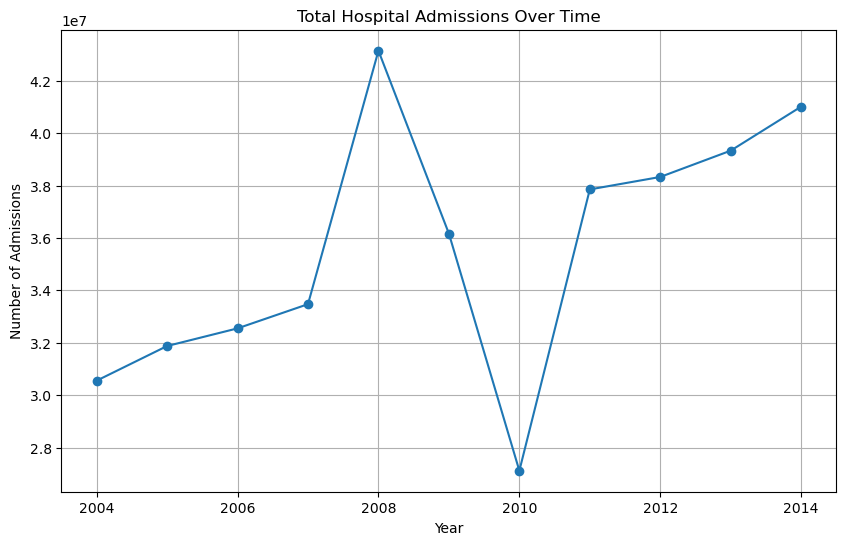

In [22]:
import matplotlib.pyplot as plt

# Group by Year and sum admissions
admissions_by_year = admissions.groupby('Year')['Value'].sum()

# Plot
plt.figure(figsize=(10, 6))
admissions_by_year.plot(kind='line', marker='o')
plt.title("Total Hospital Admissions Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Admissions")
plt.grid(True)
plt.show()

### Visualization 2 – Fatalities Over Time

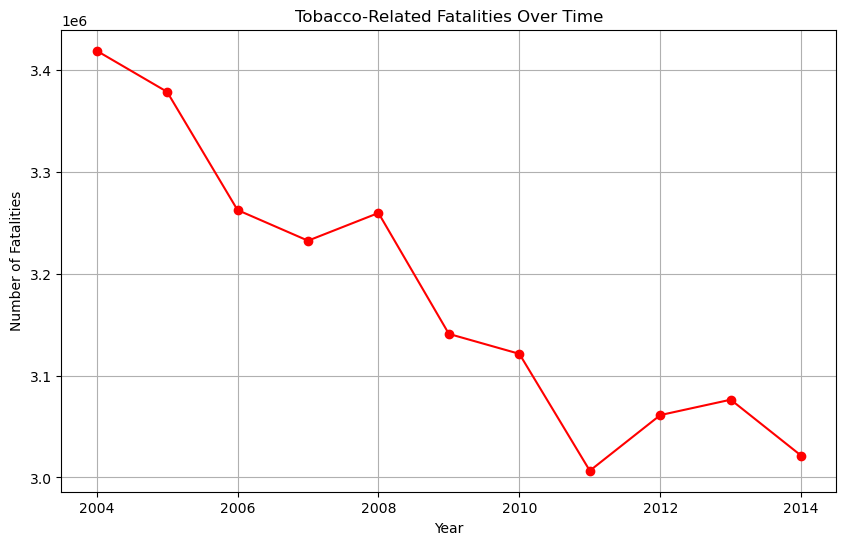

In [23]:
fatalities_by_year = fatalities.groupby('Year')['Value'].sum()

plt.figure(figsize=(10, 6))
fatalities_by_year.plot(kind='line', color='red', marker='o')
plt.title("Tobacco-Related Fatalities Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Fatalities")
plt.grid(True)
plt.show()

### Visualization 3 – Smoking Prevalence by Age Group & Gender

/opt/conda/envs/anaconda-2024.02-py310/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/envs/anaconda-2024.02-py310/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


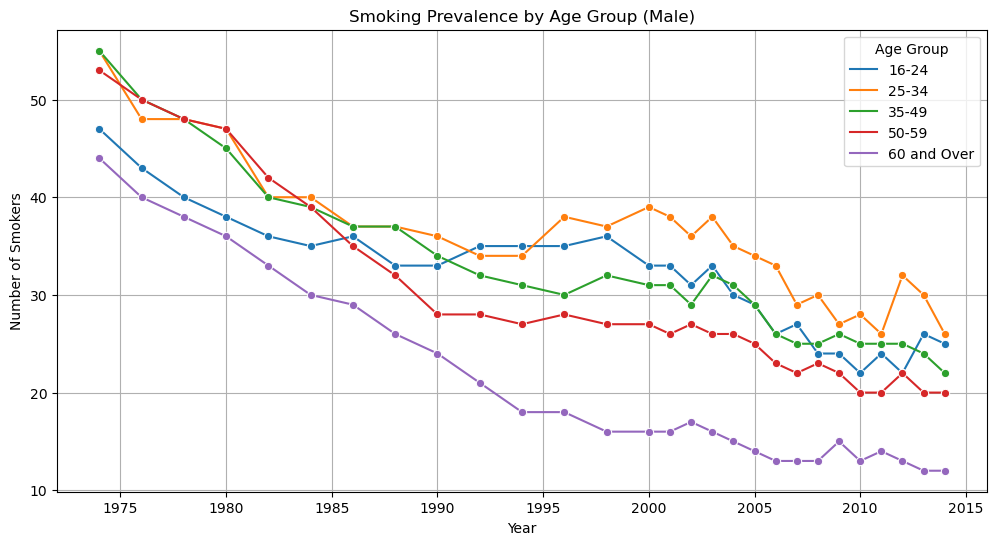

/opt/conda/envs/anaconda-2024.02-py310/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/envs/anaconda-2024.02-py310/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


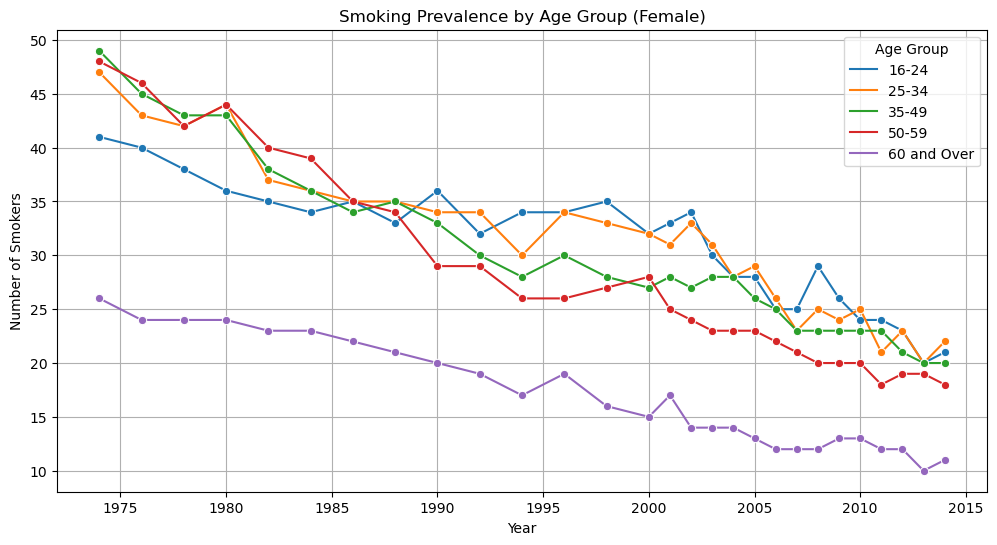

In [25]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=smokers_melted[smokers_melted['Sex']=='Male'], 
             x='Year', y='Smokers', hue='Age Group', marker='o')
plt.title("Smoking Prevalence by Age Group (Male)")
plt.ylabel("Number of Smokers")
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 6))
sns.lineplot(data=smokers_melted[smokers_melted['Sex']=='Female'], 
             x='Year', y='Smokers', hue='Age Group', marker='o')
plt.title("Smoking Prevalence by Age Group (Female)")
plt.ylabel("Number of Smokers")
plt.grid(True)
plt.show()

### Visualization 4 – Tobacco Prices & Affordability Index Over Time

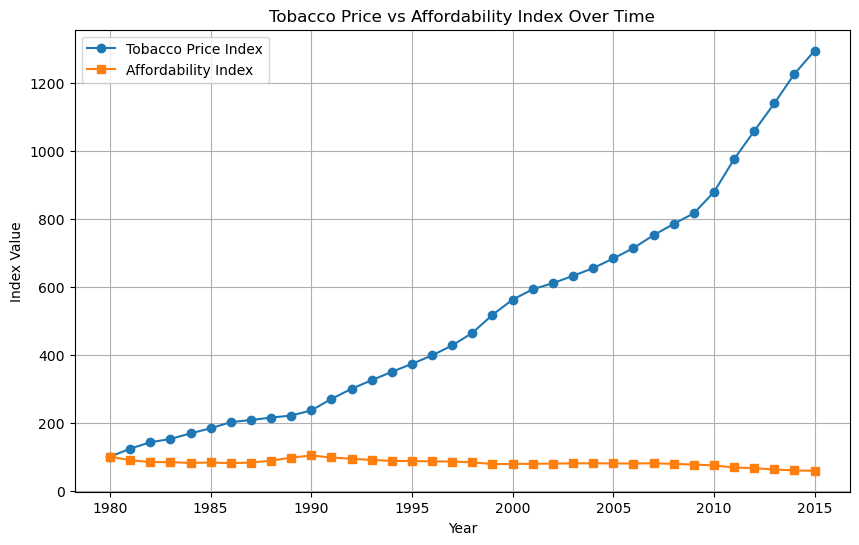

In [30]:
plt.figure(figsize=(10, 6))
plt.plot(metrics['Year'], metrics['Tobacco Price\nIndex'], label='Tobacco Price Index', marker='o')
plt.plot(metrics['Year'], metrics['Affordability of Tobacco Index'], label='Affordability Index', marker='s')
plt.title("Tobacco Price vs Affordability Index Over Time")
plt.xlabel("Year")
plt.ylabel("Index Value")
plt.legend()
plt.grid(True)
plt.show()

### Visualization 5 – Pharmacotherapy Prescriptions Trend

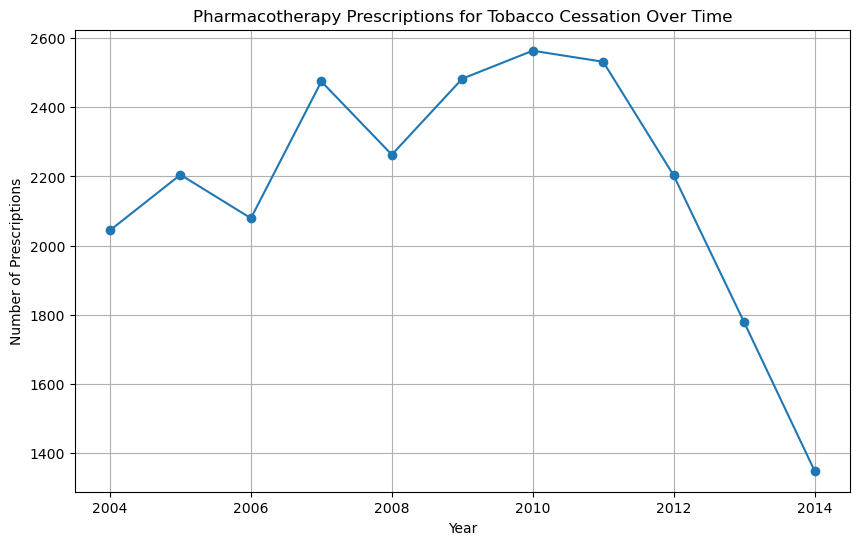

In [31]:
plt.figure(figsize=(10, 6))
plt.plot(prescriptions['Year'], prescriptions['All Pharmacotherapy Prescriptions'], marker='o')
plt.title("Pharmacotherapy Prescriptions for Tobacco Cessation Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Prescriptions")
plt.grid(True)
plt.show()

# ML MODEL

### ML Model 1: Predict Hospital Admissions

In [32]:
import pandas as pd
import numpy as np

# 1) Target: total admissions by year
adm_year = admissions.groupby('Year', as_index=False)['Value'].sum()
adm_year.rename(columns={'Value': 'Admissions'}, inplace=True)

# 2) Smokers: use Sex=='All' and the '16 and Over' column; 
#    average across different "Method" rows per year to avoid double counting.
smk_year = (
    smokers[smokers['Sex'] == 'All']
    .groupby('Year', as_index=False)['16 and Over'].mean()
    .rename(columns={'16 and Over': 'Smokers_16plus'})
)

# 3) Metrics: keep a clean subset
metric_cols = [
    'Year',
    'Tobacco Price\nIndex',
    'Retail Prices\nIndex',
    'Tobacco Price Index Relative to Retail Price Index',
    "Real Households' Disposable Income",
    'Affordability of Tobacco Index'
]
met_year = metrics[metric_cols].copy()

# 4) Prescriptions: just the total
pres_year = prescriptions[['Year', 'All Pharmacotherapy Prescriptions']].copy()
pres_year.rename(columns={'All Pharmacotherapy Prescriptions': 'Rx_All'}, inplace=True)

# 5) Merge all on Year (inner -> years available in all sources)
df = (
    adm_year
    .merge(smk_year, on='Year', how='inner')
    .merge(met_year, on='Year', how='inner')
    .merge(pres_year, on='Year', how='inner')
)

print("Modeling DF shape:", df.shape)
df.head()

Modeling DF shape: (11, 9)


,Year,Admissions,Smokers_16plus,Tobacco Price\nIndex,Retail Prices\nIndex,Tobacco Price Index Relative to Retail Price Index,Real Households' Disposable Income,Affordability of Tobacco Index,Rx_All
0,2004,30552501.0,25.0,654.6,279.3,234.4,188.7,80.5,2044
1,2005,31875961.0,24.0,683.1,287.2,237.8,190.6,80.1,2205
2,2006,32549797.0,22.0,713.7,296.4,240.8,192.3,79.9,2079
3,2007,33474110.0,21.0,751.5,309.1,243.1,195.9,80.6,2475
4,2008,43150397.0,21.0,784.7,321.3,244.2,192.5,78.8,2263


In [33]:
# Check for any remaining missing values
df.isnull().sum()


Year                                                  0
Admissions                                            0
Smokers_16plus                                        0
Tobacco Price\nIndex                                  0
Retail Prices\nIndex                                  0
Tobacco Price Index Relative to Retail Price Index    0
Real Households' Disposable Income                    0
Affordability of Tobacco Index                        0
Rx_All                                                0
dtype: int64

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import numpy as np

# Features and target
feature_cols = [
    'Smokers_16plus',
    'Tobacco Price\nIndex',
    'Retail Prices\nIndex',
    'Tobacco Price Index Relative to Retail Price Index',
    "Real Households' Disposable Income",
    'Affordability of Tobacco Index',
    'Rx_All'
]
X = df[feature_cols].values
y = df['Admissions'].values

# Train/test split (small dataset -> keep test small but stable)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# 1) Linear Regression
lin = LinearRegression()
lin.fit(X_train, y_train)
lin_pred = lin.predict(X_test)

# 2) Decision Tree (simple, then we can tune)
dt = DecisionTreeRegressor(random_state=42, max_depth=4)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

# 3) Random Forest (strong baseline)
rf = RandomForestRegressor(random_state=42, n_estimators=300, max_depth=4)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

def eval_model(name, y_true, y_hat):
    r2 = r2_score(y_true, y_hat)
    rmse = mean_squared_error(y_true, y_hat, squared=False)
    print(f"{name} -> R2: {r2:.3f} | RMSE: {rmse:,.0f}")

print("Performance on Test Set:")
eval_model("Linear Regression", y_test, lin_pred)
eval_model("Decision Tree",    y_test, dt_pred)
eval_model("Random Forest",    y_test, rf_pred)


Performance on Test Set:
Linear Regression -> R2: -35.671 | RMSE: 21,992,009
Decision Tree -> R2: -0.316 | RMSE: 4,165,839
Random Forest -> R2: 0.825 | RMSE: 1,518,378


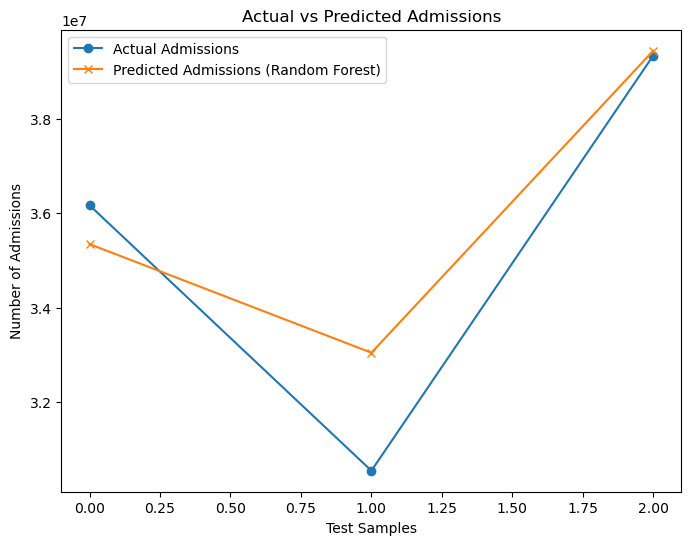

In [36]:
plt.figure(figsize=(8,6))
plt.plot(y_test, label="Actual Admissions", marker='o')
plt.plot(rf_pred, label="Predicted Admissions (Random Forest)", marker='x')
plt.title("Actual vs Predicted Admissions")
plt.xlabel("Test Samples")
plt.ylabel("Number of Admissions")
plt.legend()
plt.show()

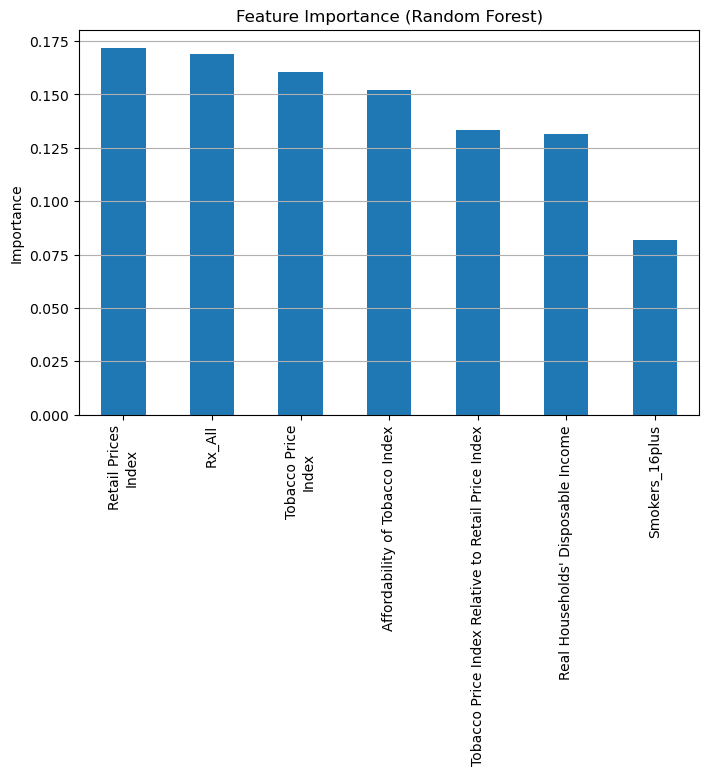

In [38]:
import pandas as pd
import matplotlib.pyplot as plt

importances = rf.feature_importances_
fi = pd.Series(importances, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(8,5))
fi.plot(kind='bar')
plt.title("Feature Importance (Random Forest)")
plt.ylabel("Importance")
plt.grid(axis='y')
plt.show()

### Model 2 – Fatalities Prediction

In [10]:
import pandas as pd

# --- Load Datasets ---
admissions_df = pd.read_csv("admissions.csv")
fatalities_df = pd.read_csv("fatalities.csv")
metrics_df = pd.read_csv("metrics.csv")
smokers_df = pd.read_csv("smokers.csv")

# --- Clean Year Columns ---
def clean_year(df, col="Year"):
    df[col] = df[col].astype(str).str.extract(r"(\d{4})")  # extract first 4-digit year
    df[col] = pd.to_numeric(df[col], errors="coerce")
    df.dropna(subset=[col], inplace=True)
    df[col] = df[col].astype(int)
    return df

fatalities_df = clean_year(fatalities_df)
metrics_df = clean_year(metrics_df)
smokers_df = clean_year(smokers_df)

# --- Clean Value Columns ---
fatalities_df["Value"] = pd.to_numeric(fatalities_df["Value"], errors="coerce")

# --- Pick yearly fatalities ---
fatalities_yearly = (
    fatalities_df[fatalities_df["ICD10 Diagnosis"]
                  .str.contains("caused by smoking", case=False, na=False)]
    .groupby("Year", as_index=False)["Value"].sum()
    .rename(columns={"Value": "Fatalities"})
)

# --- Smokers yearly average ---
smokers_yearly = smokers_df.groupby("Year", as_index=False)[["16 and Over"]].mean()

# --- Keep only common years ---
common_years = set(fatalities_yearly["Year"]) & set(metrics_df["Year"]) & set(smokers_yearly["Year"])
fatalities_yearly = fatalities_yearly[fatalities_yearly["Year"].isin(common_years)]
metrics_df = metrics_df[metrics_df["Year"].isin(common_years)]
smokers_yearly = smokers_yearly[smokers_yearly["Year"].isin(common_years)]

# --- Merge into Model 2 Dataset ---
model2_df = fatalities_yearly.merge(metrics_df, on="Year").merge(smokers_yearly, on="Year")

print("Model 2 DataFrame Shape:", model2_df.shape)
print(model2_df.head())


Model 2 DataFrame Shape: (11, 11)
   Year  Fatalities  Tobacco Price\nIndex  Retail Prices\nIndex  \
0  2004    578816.0                 654.6                 279.3   
1  2005    567130.0                 683.1                 287.2   
2  2006    543550.0                 713.7                 296.4   
3  2007    534360.0                 751.5                 309.1   
4  2008    535102.0                 784.7                 321.3   

   Tobacco Price Index Relative to Retail Price Index  \
0                                              234.4    
1                                              237.8    
2                                              240.8    
3                                              243.1    
4                                              244.2    

   Real Households' Disposable Income  Affordability of Tobacco Index  \
0                               188.7                            80.5   
1                               190.6                            80.1   
2

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Features and Target
X = model2_df.drop(columns=["Fatalities", "Year"])
y = model2_df["Fatalities"]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- Linear Regression ---
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

# --- Decision Tree Regressor ---
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

# --- Random Forest Regressor ---
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

# --- Evaluation Function ---
def evaluate_model(name, y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"{name} -> R2: {r2:.3f} | RMSE: {rmse:,.0f}")

print("\nPerformance on Test Set:")
evaluate_model("Linear Regression", y_test, lr_pred)
evaluate_model("Decision Tree", y_test, dt_pred)
evaluate_model("Random Forest", y_test, rf_pred)



Performance on Test Set:
Linear Regression -> R2: 0.764 | RMSE: 19,467
Decision Tree -> R2: 0.828 | RMSE: 16,596
Random Forest -> R2: 0.843 | RMSE: 15,868


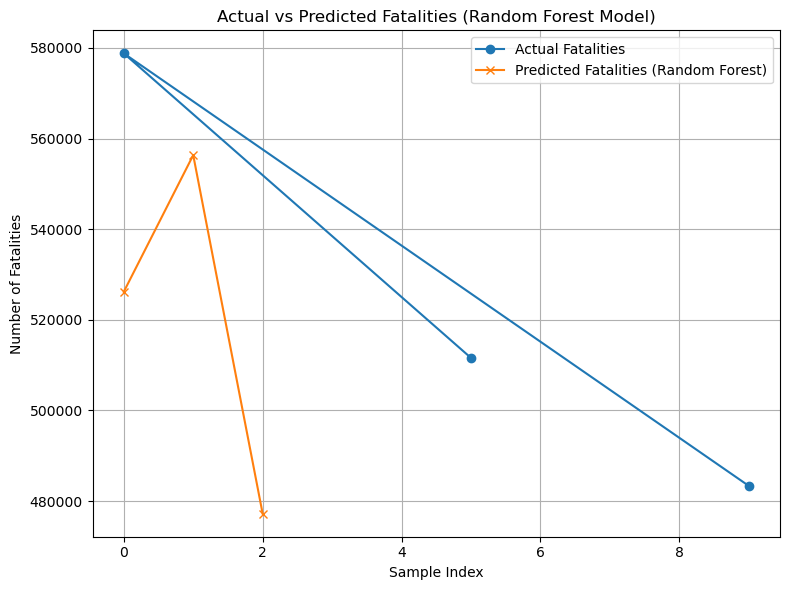

In [13]:
import matplotlib.pyplot as plt

# Use the same variable names from your model training
plt.figure(figsize=(8, 6))
plt.plot(y_test, label="Actual Fatalities", marker='o')
plt.plot(rf_pred, label="Predicted Fatalities (Random Forest)", marker='x')

plt.title("Actual vs Predicted Fatalities (Random Forest Model)")
plt.xlabel("Sample Index")
plt.ylabel("Number of Fatalities")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Model 3 – Smokers Prediction

16-24: R2 = 0.846, RMSE = 2.36
25-34: R2 = 0.691, RMSE = 4.31
35-49: R2 = 0.887, RMSE = 2.85
50-59: R2 = 0.917, RMSE = 2.80
60 and Over: R2 = 0.593, RMSE = 5.77


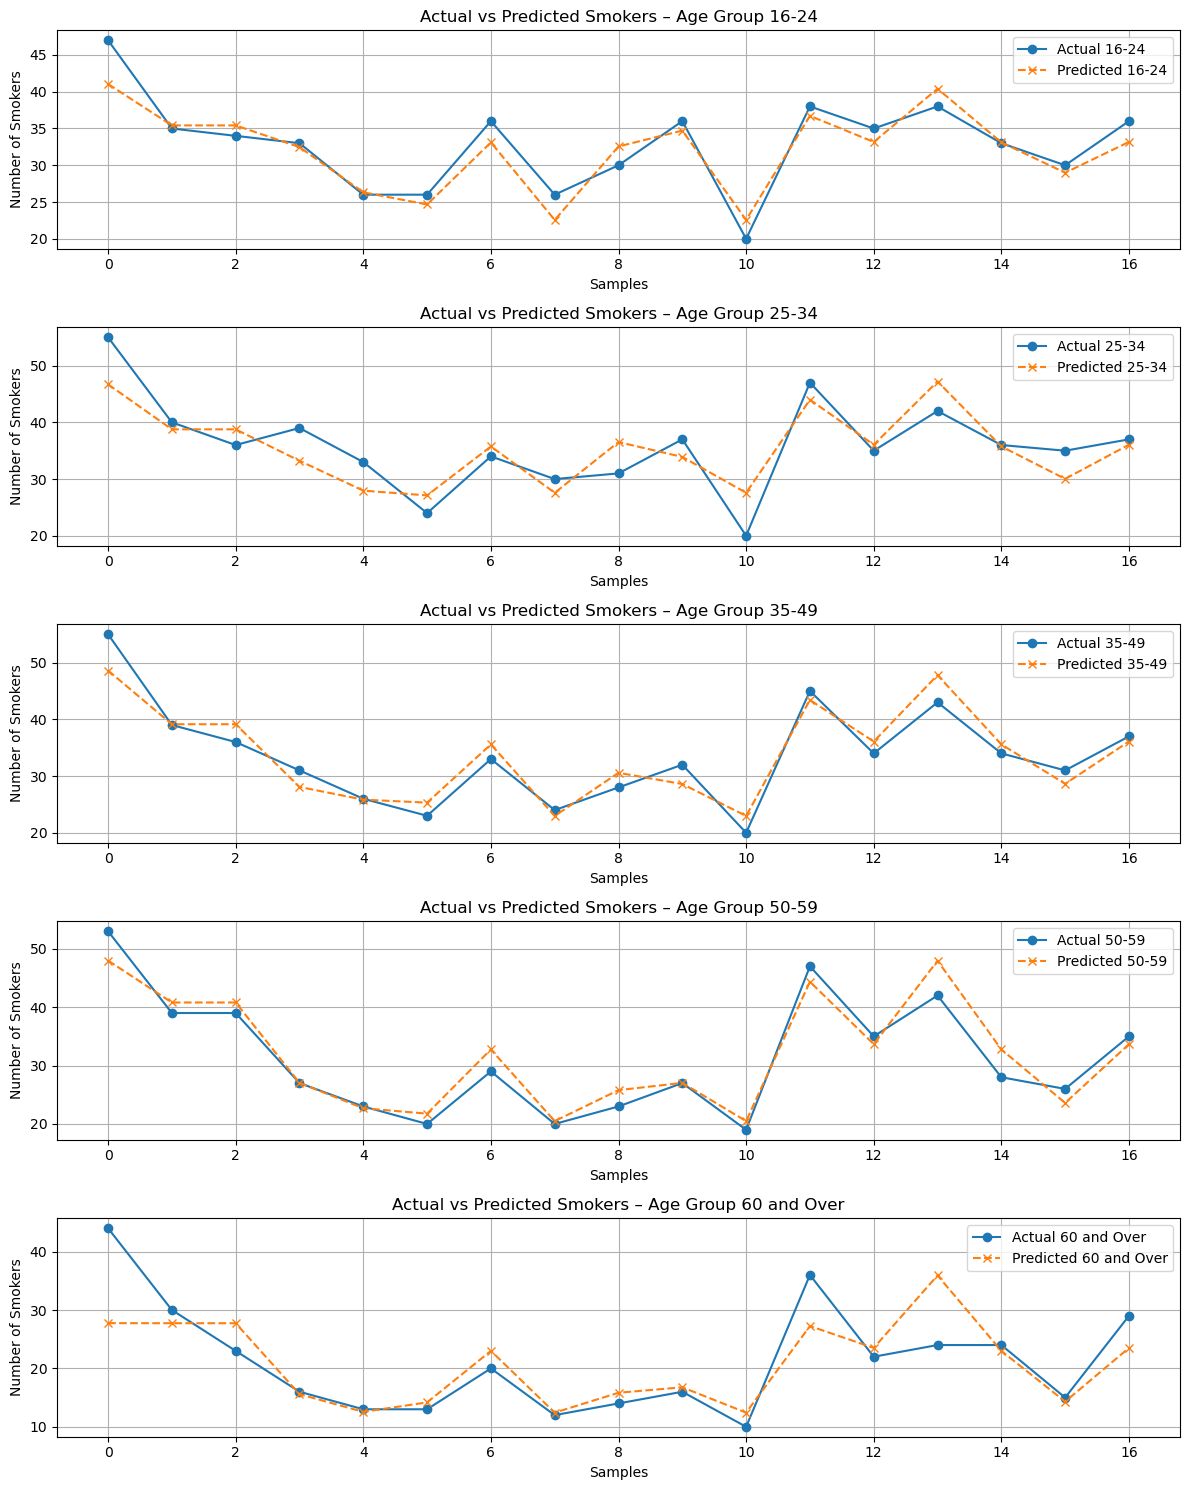

In [19]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt

# -------------------
# 1. Load & Clean Data
# -------------------
# Load smokers dataset
smokers_df = pd.read_csv("smokers.csv")

# Drop rows with missing values
smokers_df.dropna(inplace=True)

# Select features & target columns
features = ["Year"]  # Could add metrics like price, income if merged
targets = ["16-24", "25-34", "35-49", "50-59", "60 and Over"]

X = smokers_df[features]
y = smokers_df[targets]

# -------------------
# 2. Train-Test Split
# -------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# -------------------
# 3. Train Model
# -------------------
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# -------------------
# 4. Predict & Evaluate
# -------------------
y_pred = rf_model.predict(X_test)

# Calculate R² & RMSE for each age group
for i, col in enumerate(targets):
    r2 = r2_score(y_test[col], y_pred[:, i])
    rmse = mean_squared_error(y_test[col], y_pred[:, i], squared=False)
    print(f"{col}: R2 = {r2:.3f}, RMSE = {rmse:.2f}")

# -------------------
# 5. Visualization
# -------------------
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 15))  # Bigger figure for clarity

for i, col in enumerate(targets):
    plt.subplot(len(targets), 1, i + 1)
    plt.plot(y_test[col].values, label=f"Actual {col}", marker='o')
    plt.plot(y_pred[:, i], label=f"Predicted {col}", marker='x', linestyle='--')
    plt.title(f"Actual vs Predicted Smokers – Age Group {col}")
    plt.xlabel("Samples")
    plt.ylabel("Number of Smokers")
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()
